---

# IF3270 Pembelajaran Mesin | Praktikum 4
## Recurrent Neural Network

---

**Nomor Kelompok:** K1-80

**Anggota Kelompok:**
- 13523002 - Refki Alfarizi
- 13523004 - Razi Rachman Widyadhana

## Daftar Isi

0. [**Inisialisasi**](#0)
1. [**Muat Dataset**](#1)
2. [**Analisis Data Eksploratif**](#2)
3. [**Pembersihan Data**](#3)
4. [**Prapemrosesan Data**](#4)
5. [**Pemodelan dan Validasi**](#5)
6. [**Analisis Kesalahan**](#6)

---

# Inisialisasi <a name="0"></a>

---

## Informasi Lingkungan

In [1]:
import sys, platform
from pathlib import Path
print('Python  :', sys.version)
print('OS      :', platform.platform())
print('CWD     :', Path.cwd())

Python  : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
OS      : Linux-6.6.113+-x86_64-with-glibc2.35
CWD     : /kaggle/working


## Instalasi Dependensi

In [2]:
# %pip install -q torch torchvision torchaudio
# %pip install -q numpy pandas matplotlib seaborn scikit-learn tqdm

## Impor Pustaka

In [3]:
import math
import os
import platform
import random
import sys
import warnings
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
print('PyTorch :', torch.__version__)
print('CUDA    :', torch.version.cuda)
print('Device  :', 'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch : 2.10.0+cu128
CUDA    : 12.8
Device  : cuda


## Settings

Kelas `Settings` memusatkan seluruh konfigurasi eksperimen, mencakup jalur data dan *hyperparameter* pelatihan. Jalur data diselesaikan secara otomatis bergantung pada lingkungan eksekusi, yaitu Kaggle atau lokal. Empat parameter mengontrol perilaku modular, yaitu `INPUT_COLS` untuk fitur input (ubah ke beberapa kolom untuk mode *multivariate*), `VAL_STRATEGY` untuk strategi validasi, `INFER_MODE` yang menentukan cara prediksi data uji, di mana `'multistep'` memprediksi semua langkah sekaligus dalam satu *forward pass* sedangkan `'autoregressive'` menggunakan prediksi sebelumnya sebagai input untuk langkah berikutnya, serta `REGIME_FILTER` yang membatasi pelatihan hanya pada jendela *high-regime* (h1 > `REGIME_THRESHOLD`) sehingga *scaler* mendapatkan resolusi penuh pada rentang nilai yang relevan dengan data uji. Tidak ada kode lain yang perlu diubah.

In [4]:
class Settings:
    SEED   = 42

    # Kolom data
    TIME_COL   = 'time'
    TARGET_COL = 'h1'
    INPUT_COLS = ['h1']   # ganti ke ['WIND', 'RAIN', ...] untuk multivariate

    # Arsitektur model
    INPUT_SIZE  = len(INPUT_COLS)  # otomatis mengikuti INPUT_COLS
    HIDDEN_SIZE = 64
    NUM_LAYERS  = 2
    DROPOUT     = 0.2

    # Strategi inferensi
    INFER_MODE  = 'autoregressive'  # 'autoregressive' | 'multistep'
    HORIZON     = 1500               # langkah prediksi langsung (hanya saat INFER_MODE='multistep')
    OUTPUT_SIZE = HORIZON if INFER_MODE == 'multistep' else 1

    # Preprocessing
    WINDOW_SIZE      = 30
    REGIME_FILTER    = True    # True: latih hanya pada window high-regime
    REGIME_THRESHOLD = 50000   # ambang batas h1 (asli) untuk high-regime

    # Pelatihan
    EPOCHS              = 100
    BATCH_SIZE          = 32
    LR                  = 1e-3
    WEIGHT_DECAY        = 1e-4
    EARLY_STOP_PATIENCE = 15

    # Pembersihan data
    CLEANING           = True  # kontrol deteksi anomali (flat-line, scale jump)
    NAN_SHORT_THRESHOLD = 7    # run NaN <= ini diinterpolasi; lebih panjang di-forward fill + peringatan

    # Strategi validasi
    VAL_STRATEGY = 'holdout'  # 'holdout' | 'tscv'
    VAL_SPLIT    = 0.2        # digunakan saat VAL_STRATEGY == 'holdout'
    N_SPLITS     = 5          # jumlah fold (digunakan saat VAL_STRATEGY == 'tscv')

    # Jalur data
    _ON_KAGGLE   = Path('/kaggle/input').exists()
    _LOCAL_DATA  = Path('data/univariate')
    _KAGGLE_DATA = Path('/kaggle/input/competitions/praktikum-3-if-3270-ml')
    DATA_DIR  = _KAGGLE_DATA if _ON_KAGGLE else _LOCAL_DATA
    TRAIN_CSV = DATA_DIR / 'train.csv'
    TEST_CSV  = DATA_DIR / 'test.csv'

    # Jalur output
    _BASE_OUT       = Path('/kaggle/working') if _ON_KAGGLE else Path('output')
    OUTPUT_DIR      = _BASE_OUT / 'prak4'
    CHECKPOINT_RNN  = OUTPUT_DIR / 'rnn_best.pth'
    CHECKPOINT_LSTM = OUTPUT_DIR / 'lstm_best.pth'
    SUBMISSION_RNN  = OUTPUT_DIR / 'submission_rnn.csv'
    SUBMISSION_LSTM = OUTPUT_DIR / 'submission_lstm.csv'

CFG = Settings()
CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', DEVICE)
print('Output :', CFG.OUTPUT_DIR)

Device : cuda
Output : /kaggle/working/prak4


## Pengaturan Seed

In [5]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG.SEED)

---

# Muat Dataset <a name="1"></a>

---

Dataset terdiri dari dua berkas CSV, yaitu `train.csv` untuk pelatihan dan `test.csv` sebagai data uji kompetisi Kaggle. Kolom `time` dikonversi menjadi tipe *datetime* dan dijadikan indeks agar pemrosesan deret waktu lebih mudah dilakukan.

In [6]:
train_df = pd.read_csv(CFG.TRAIN_CSV, parse_dates=[CFG.TIME_COL], index_col=CFG.TIME_COL)
test_df  = pd.read_csv(CFG.TEST_CSV,  parse_dates=[CFG.TIME_COL], index_col=CFG.TIME_COL)

## Pratinjau Data Latih

Lima baris pertama data latih memberikan gambaran awal tentang struktur kolom dan rentang nilai `h1`.

In [7]:
train_df

,h1
time,
2022-01-01,16853.0
2022-01-02,14155.0
2022-01-03,14439.0
2022-01-04,11273.0
2022-01-05,10750.0
...,...
2045-04-05,140132.0
2045-04-06,140818.0
2045-04-07,129793.0


---

# Analisis Data Eksploratif <a name="2"></a>

---

Tahap ini memeriksa struktur dan karakteristik dataset sebelum dilakukan transformasi apa pun. Fokus diberikan pada ringkasan statistik dasar, pola deret waktu, dan identifikasi anomali yang dapat memengaruhi pelatihan model.

## Analisis 1: Statistik Deskriptif

Ringkasan statistik memberikan gambaran distribusi nilai `h1`, mencakup rentang, rata-rata, dan indikasi persebaran data.

In [8]:
desc = train_df[CFG.TARGET_COL].describe()
print(desc.to_string())

count      8500.000000
mean      68741.047176
std       74838.021892
min          75.000000
25%        4656.000000
50%       15448.000000
75%      142834.500000
max      288630.000000


> ### Insights
> Isi ringkasan statistik dan temuan awal di sini setelah notebook dijalankan.

## Analisis 2: Visualisasi Deret Waktu

Grafik deret waktu memperlihatkan pola keseluruhan nilai `h1` sepanjang rentang data latih, sehingga anomali seperti loncatan skala atau segmen nilai konstan lebih mudah teridentifikasi secara visual.

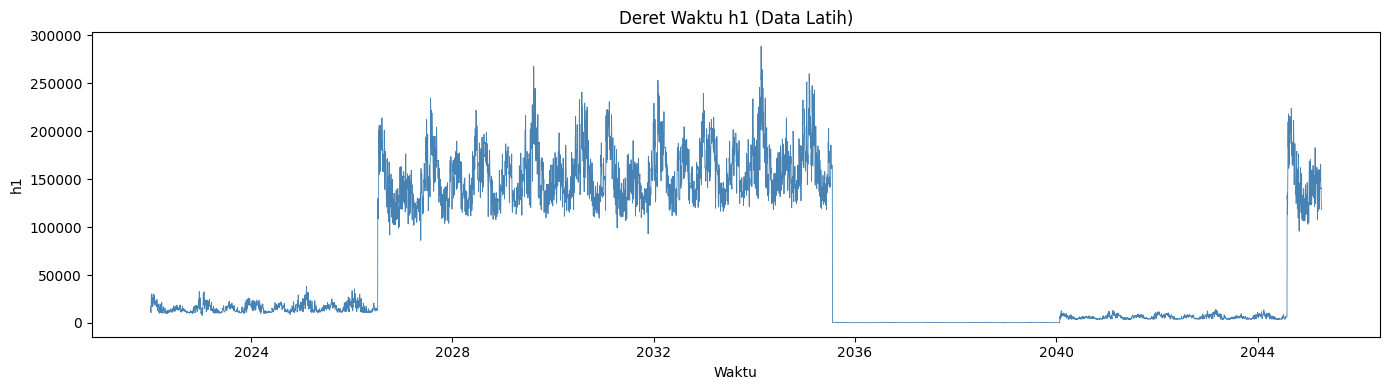

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_df.index, train_df[CFG.TARGET_COL], linewidth=0.6, color='steelblue')
ax.set_title('Deret Waktu h1 (Data Latih)')
ax.set_xlabel('Waktu')
ax.set_ylabel('h1')
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'eda_timeseries.png', dpi=120)
plt.show()

### Deteksi Flat-Line (Nilai Konstan Berurutan)

Segmen dengan nilai identik selama beberapa hari berturut-turut berpotensi merupakan data yang diisi ke depan (*forward-filled*) akibat nilai yang hilang, bukan nilai pengukuran sesungguhnya.

In [10]:
def detect_flat_runs(series, min_len=3):
    runs = []
    start = 0
    for i in range(1, len(series)):
        if series.iloc[i] != series.iloc[i - 1]:
            if i - start >= min_len:
                runs.append({
                    'start': series.index[start],
                    'end':   series.index[i - 1],
                    'length': i - start,
                    'value': series.iloc[start],
                })
            start = i
    if len(series) - start >= min_len:
        runs.append({
            'start': series.index[start],
            'end':   series.index[-1],
            'length': len(series) - start,
            'value': series.iloc[start],
        })
    return pd.DataFrame(runs)

flat_df = detect_flat_runs(train_df[CFG.TARGET_COL], min_len=3)
print(f'Segmen flat-line ditemukan: {len(flat_df)}')
display(flat_df)

Segmen flat-line ditemukan: 45


,start,end,length,value
0,2023-03-06,2023-03-13,8,17345.0
1,2023-06-20,2023-06-27,8,11494.0
2,2023-09-10,2023-09-17,8,11831.0
3,2023-12-25,2024-01-01,8,18604.0
4,2024-02-13,2024-02-20,8,21443.0
5,2024-05-24,2024-05-31,8,11053.0
6,2024-08-01,2024-08-08,8,21812.0
7,2024-11-21,2024-11-28,8,19577.0
8,2026-07-01,2026-07-08,8,13008.0
9,2027-09-11,2027-09-18,8,169539.0


### Deteksi Loncatan Skala

In [11]:
pct_change = train_df[CFG.TARGET_COL].pct_change().abs()
threshold  = 5.0   # lebih dari 500% perubahan
jumps = pct_change[pct_change > threshold].dropna()
print(f'Loncatan besar (>500%) ditemukan: {len(jumps)}')
if not jumps.empty:
    display(train_df.loc[jumps.index, [CFG.TARGET_COL]])

Loncatan besar (>500%) ditemukan: 3


,h1
time,
2026-07-09,126259.0
2040-01-27,6829.0
2044-08-03,133088.0


## Analisis 3: Autokorelasi

Plot autokorelasi memperlihatkan seberapa kuat nilai `h1` pada waktu `t` berkorelasi dengan nilai pada `t - lag`. Puncak signifikan di lag 7 dan 365 mengonfirmasi adanya siklus mingguan dan tahunan, serta menjadi dasar penentuan ukuran *window* yang representatif.

Autokorelasi pada lag kunci:
  lag    7 : +0.9724
  lag   14 : +0.9618
  lag   30 : +0.9340
  lag   90 : +0.8638
  lag  182 : +0.8304
  lag  365 : +0.7444
  lag  730 : +0.5456


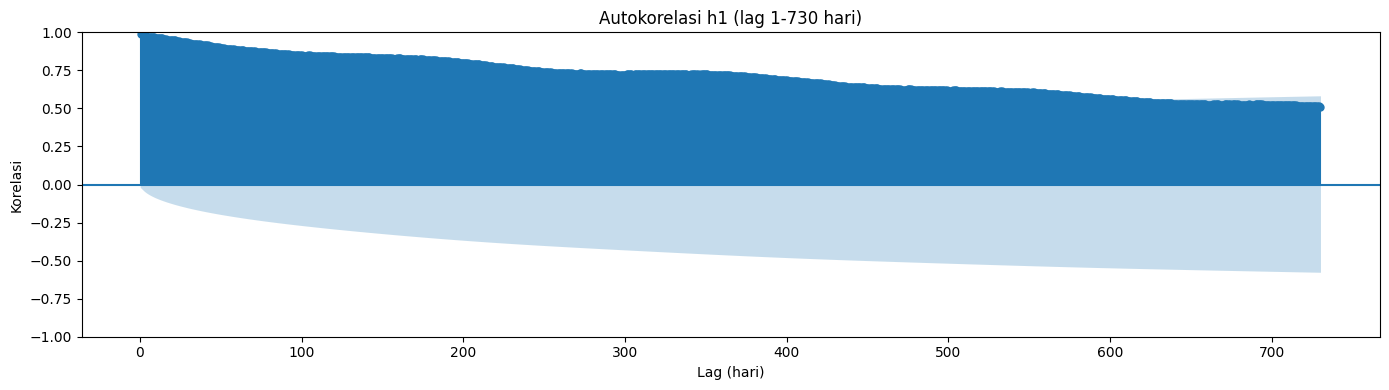

In [12]:
series = train_df[CFG.TARGET_COL].dropna()
key_lags = [7, 14, 30, 90, 182, 365, 730]
acf_vals = {lag: round(series.autocorr(lag=lag), 4) for lag in key_lags}
print('Autokorelasi pada lag kunci:')
for lag, val in acf_vals.items():
    print(f'  lag {lag:4d} : {val:+.4f}')

fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(series, lags=730, ax=ax, alpha=0.05, zero=False)
ax.set_title('Autokorelasi h1 (lag 1-730 hari)')
ax.set_xlabel('Lag (hari)')
ax.set_ylabel('Korelasi')
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'eda_acf.png', dpi=120)
plt.show()

## Analisis 4: Dekomposisi Musiman

Dekomposisi aditif memisahkan deret waktu menjadi tiga komponen, yaitu tren jangka panjang, musiman dengan periode 365 hari, dan residu. Komponen musiman yang kuat menandakan bahwa informasi kalender perlu diberikan secara eksplisit kepada model sebagai fitur tambahan.

Rentang komponen musiman : -12956.36 --> 17174.02
Rentang komponen tren    : 383.76 --> 168462.71
Rentang komponen residu  : -89809.34 --> 123460.02
Kekuatan musiman (F_s)   : 0.1066  (>0.6 = kuat, >0.4 = sedang)
Rasio varian musiman     : 1.1% dari total varian


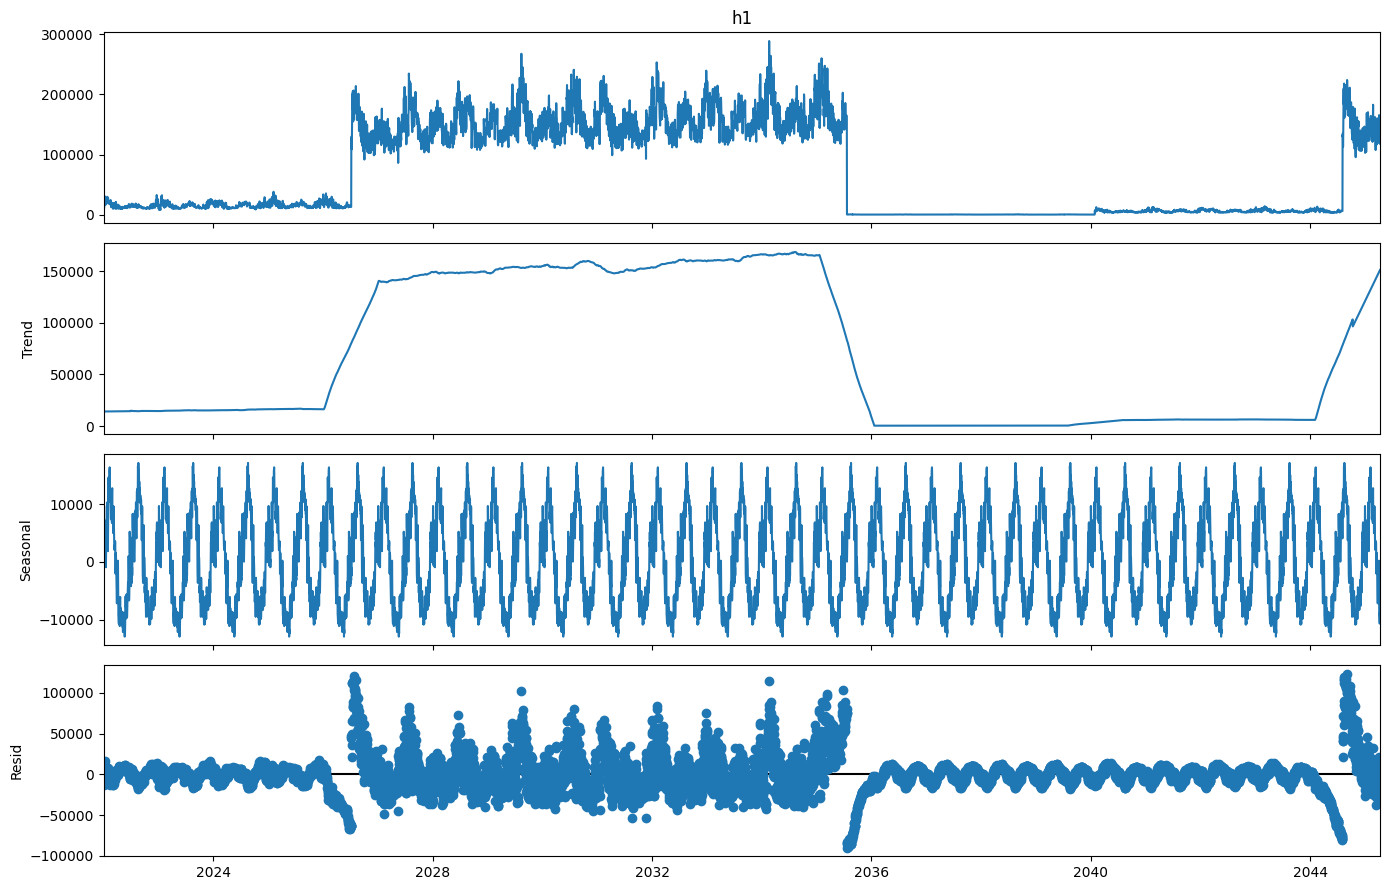

In [13]:
decomp = seasonal_decompose(
    train_df[CFG.TARGET_COL].dropna(),
    model='additive',
    period=365,
    extrapolate_trend='freq',
)

var_seasonal  = decomp.seasonal.var()
var_residual  = decomp.resid.dropna().var()
var_total     = train_df[CFG.TARGET_COL].dropna().var()
seasonal_str  = 1 - var_residual / (var_seasonal + var_residual)
print(f'Rentang komponen musiman : {decomp.seasonal.min():.2f} --> {decomp.seasonal.max():.2f}')
print(f'Rentang komponen tren    : {decomp.trend.min():.2f} --> {decomp.trend.max():.2f}')
print(f'Rentang komponen residu  : {decomp.resid.dropna().min():.2f} --> {decomp.resid.dropna().max():.2f}')
print(f'Kekuatan musiman (F_s)   : {seasonal_str:.4f}  (>0.6 = kuat, >0.4 = sedang)')
print(f'Rasio varian musiman     : {var_seasonal / var_total * 100:.1f}% dari total varian')

fig = decomp.plot()
fig.set_size_inches(14, 9)
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'eda_decomposition.png', dpi=120)
plt.show()

## Analisis 5: Pola Mingguan dan Tahunan

Distribusi `h1` dikelompokkan per hari dalam seminggu dan per bulan untuk mengukur seberapa besar variasi kalender memengaruhi beban listrik. Variasi yang jelas antara hari kerja dan akhir pekan, atau antara musim panas dan musim dingin, menjadi argumen kuat untuk menyertakan fitur `sin/cos` hari-dalam-tahun dan hari-dalam-seminggu sebagai input model.

Statistik per Hari dalam Seminggu:
     Rata-rata   Median      Std
Sen    68688.4  15968.0  74847.6
Sel    70437.7  15655.5  76884.3
Rab    70615.8  15284.5  76846.2
Kam    69628.0  15186.5  75727.2
Jum    67396.0  15200.5  73140.7
Sab    67124.4  15640.0  73044.2
Min    67299.6  15424.0  73356.7

Statistik per Bulan:
     Rata-rata   Median      Std
Jan    72159.9  21362.5  76271.6
Feb    79787.2  21382.0  85324.8
Mar    71690.0  16036.0  77549.1
Apr    59946.9  11697.0  66729.2
Mei    57341.5  11607.0  64828.8
Jun    64930.7  14341.0  74106.9
Jul    70435.8  16494.0  77228.5
Agu    81107.7  18230.0  86191.5
Sep    72834.0  13020.5  77621.5
Okt    62044.3  11933.0  65736.5
Nov    62080.4  15983.0  64926.1
Des    70421.1  20124.0  73883.2

Rentang rata-rata harian : 67124.4 - 70615.8
Rentang rata-rata bulanan: 57341.5 - 81107.7


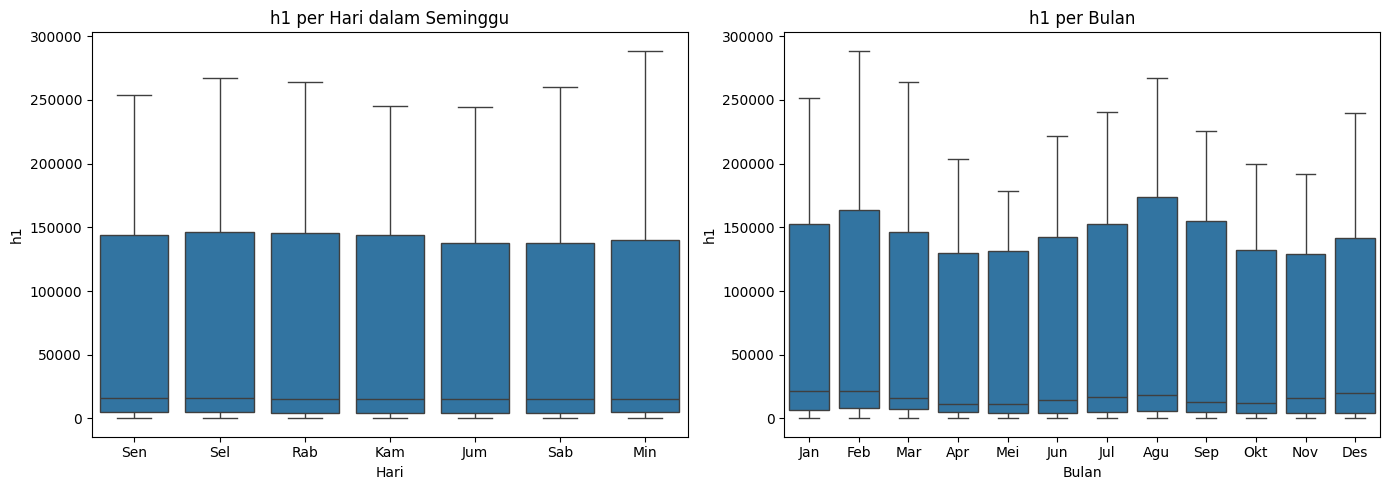

In [14]:
tmp = train_df[[CFG.TARGET_COL]].copy()
tmp['hari']  = tmp.index.dayofweek
tmp['bulan'] = tmp.index.month

day_labels   = ['Sen', 'Sel', 'Rab', 'Kam', 'Jum', 'Sab', 'Min']
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun',
                'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']

dow_stats = tmp.groupby('hari')[CFG.TARGET_COL].agg(['mean', 'median', 'std'])
dow_stats.index = day_labels
dow_stats.columns = ['Rata-rata', 'Median', 'Std']
print('Statistik per Hari dalam Seminggu:')
print(dow_stats.round(1).to_string())

mon_stats = tmp.groupby('bulan')[CFG.TARGET_COL].agg(['mean', 'median', 'std'])
mon_stats.index = month_labels
mon_stats.columns = ['Rata-rata', 'Median', 'Std']
print('\nStatistik per Bulan:')
print(mon_stats.round(1).to_string())

print(f'\nRentang rata-rata harian : {dow_stats["Rata-rata"].min():.1f} - {dow_stats["Rata-rata"].max():.1f}')
print(f'Rentang rata-rata bulanan: {mon_stats["Rata-rata"].min():.1f} - {mon_stats["Rata-rata"].max():.1f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=tmp, x='hari',  y=CFG.TARGET_COL, ax=axes[0], showfliers=False)
axes[0].set_xticklabels(day_labels)
axes[0].set_title('h1 per Hari dalam Seminggu')
axes[0].set_xlabel('Hari')
axes[0].set_ylabel('h1')

sns.boxplot(data=tmp, x='bulan', y=CFG.TARGET_COL, ax=axes[1], showfliers=False)
axes[1].set_xticklabels(month_labels)
axes[1].set_title('h1 per Bulan')
axes[1].set_xlabel('Bulan')
axes[1].set_ylabel('h1')

plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'eda_seasonal_patterns.png', dpi=120)
plt.show()

> ### Insights
> Isi temuan EDA di sini setelah notebook dijalankan: anomali flat-line, loncatan > skala, kekuatan autokorelasi pada lag 7 dan 365, komponen musiman dari dekomposisi, > serta pola mingguan dan tahunan yang mengindikasikan perlunya fitur kalender.

---

# Pembersihan Data <a name="3"></a>

---

Pembersihan terdiri dari dua lapis.

- NaN di awal seri dipotong karena tidak ada nilai sebelumnya untuk diinterpolasi
- Gap pendek (<= `NAN_SHORT_THRESHOLD`) diisi dengan interpolasi linear
- Gap panjang diisi secara *forward fill*
- Deteksi anomali flat-line dan loncatan skala dijalankan hanya jika `CFG.CLEANING = True`

## Penanganan NaN

Fungsi `handle_nan` menerapkan strategi bertingkat: baris di awal seri yang seluruhnya NaN dipotong karena tidak ada nilai sebelumnya untuk diinterpolasi, gap pendek diisi dengan interpolasi linear, dan gap panjang diisi secara *forward fill* sebagai fallback.

In [15]:
train_clean = train_df.copy()

def handle_nan(series):
    s = series.copy()
    # 1. Potong leading NaN
    first_valid = s.first_valid_index()
    if first_valid is None:
        print('[NaN] Seluruh seri adalah NaN.')
        return s
    if first_valid != s.index[0]:
        n_cut = s.index.get_loc(first_valid)
        print(f'[NaN] {n_cut} baris awal dipotong (leading NaN).')
        s = s.loc[first_valid:]
    if not s.isna().any():
        print('[NaN] Tidak ada NaN.')
        return s
    # 2. Klasifikasi run NaN
    null_mask  = s.isna()
    run_id     = (null_mask != null_mask.shift()).cumsum()
    run_len    = null_mask.groupby(run_id).transform('sum')
    short_mask = null_mask & (run_len <= CFG.NAN_SHORT_THRESHOLD)
    long_mask  = null_mask & (run_len >  CFG.NAN_SHORT_THRESHOLD)
    print(f'[NaN] Run pendek (<={CFG.NAN_SHORT_THRESHOLD} hari): {short_mask.sum()} nilai -> interpolasi linear')
    print(f'[NaN] Run panjang (>{CFG.NAN_SHORT_THRESHOLD} hari): {long_mask.sum()} nilai -> forward fill')
    # 3. Interpolasi run pendek, forward fill run panjang
    s = s.interpolate(method='linear', limit=CFG.NAN_SHORT_THRESHOLD)
    s = s.ffill().bfill()
    print(f'[NaN] Sisa NaN setelah semua strategi: {s.isna().sum()}')
    return s

train_clean[CFG.TARGET_COL] = handle_nan(train_clean[CFG.TARGET_COL])
print(f'Shape setelah penanganan NaN: {train_clean.shape}')

[NaN] Tidak ada NaN.
Shape setelah penanganan NaN: (8500, 1)


## Pembersihan Anomali

Segmen flat-line dari EDA diganti dengan NaN lalu diinterpolasi secara linear. Loncatan skala hanya dilaporkan tanpa modifikasi karena merupakan karakteristik deret waktu yang harus dipelajari model.

In [16]:
if CFG.CLEANING:
    # Ganti segmen flat-line dengan NaN lalu interpolasi
    for _, row in flat_df.iterrows():
        mask = (train_clean.index >= row['start']) & (train_clean.index <= row['end'])
        train_clean.loc[mask, CFG.TARGET_COL] = np.nan
    n_nan = train_clean[CFG.TARGET_COL].isna().sum()
    print(f'NaN setelah penandaan flat-line : {n_nan}')
    train_clean[CFG.TARGET_COL] = train_clean[CFG.TARGET_COL].interpolate(method='linear')
    print(f'NaN setelah interpolasi         : {train_clean[CFG.TARGET_COL].isna().sum()}')
    # Laporkan loncatan skala (tidak diubah; model perlu mempelajarinya)
    pct_change = train_clean[CFG.TARGET_COL].pct_change().abs()
    jumps = pct_change[pct_change > 5.0].dropna()
    print(f'Loncatan skala besar (>500%) : {len(jumps)}')
    if not jumps.empty:
        display(train_clean.loc[jumps.index, [CFG.TARGET_COL]])
else:
    print('[Pembersihan] CLEANING=False, deteksi anomali dilewati.')

NaN setelah penandaan flat-line : 360
NaN setelah interpolasi         : 0
Loncatan skala besar (>500%) : 0


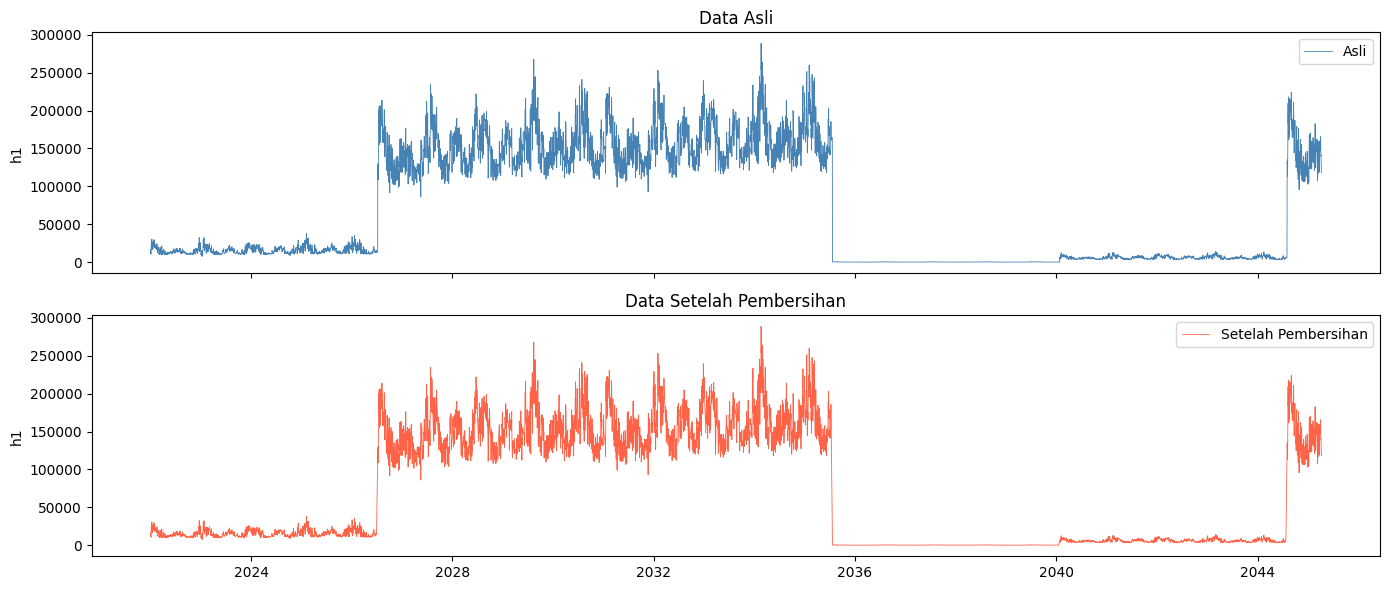

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(train_df.index, train_df[CFG.TARGET_COL],   linewidth=0.6, color='steelblue', label='Asli')
axes[1].plot(train_clean.index, train_clean[CFG.TARGET_COL], linewidth=0.6, color='tomato',    label='Setelah Pembersihan')
for ax in axes:
    ax.set_ylabel('h1')
    ax.legend()
axes[0].set_title('Data Asli')
axes[1].set_title('Data Setelah Pembersihan')
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'cleaning_comparison.png', dpi=120)
plt.show()

> ### Insights
> Isi evaluasi hasil pembersihan di sini setelah notebook dijalankan.

---

# Prapemrosesan Data <a name="4"></a>

---

Prapemrosesan mencakup tiga langkah utama, yaitu *scaling* untuk menormalkan rentang nilai, *sliding window* untuk mengubah deret waktu menjadi pasangan input-target, dan pembagian data latih serta validasi tanpa pengacakan agar urutan waktu tetap terjaga. Strategi pembagian dikontrol oleh `CFG.VAL_STRATEGY`, di mana `'holdout'` menggunakan satu pembagian temporal 80/20 sedangkan `'tscv'` menerapkan *time series cross-validation* dengan `CFG.N_SPLITS` fold.

## Scaling

`MinMaxScaler` dilatih hanya pada data latih untuk menghindari *data leakage*. Ketika `CFG.REGIME_FILTER=True`, *scaler* dilatih hanya pada baris *high-regime* (h1 > `REGIME_THRESHOLD`) sehingga rentang [0, 1] mencakup sepenuhnya variasi pada regime yang relevan dengan data uji. Skala yang sama kemudian diterapkan pada seluruh data latih.

In [18]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_values = train_clean[CFG.TARGET_COL].values.reshape(-1, 1)

if CFG.REGIME_FILTER:
    high_mask = train_clean[CFG.TARGET_COL] > CFG.REGIME_THRESHOLD
    scaler.fit(train_values[high_mask.values])
    print(f'[Regime] Scaler dilatih pada {high_mask.sum()} baris '
          f'high-regime (h1 > {CFG.REGIME_THRESHOLD})')
else:
    scaler.fit(train_values)

scaled_values = scaler.transform(train_values).flatten()

train_scaled_df = pd.DataFrame(
    {CFG.TARGET_COL: scaled_values},
    index=train_clean.index
)
print('Rentang sebelum scaling :', train_values.min(), '-->', train_values.max())
print('Rentang setelah scaling  :', scaled_values.min(), '-->', scaled_values.max())

[Regime] Scaler dilatih pada 3559 baris high-regime (h1 > 50000)
Rentang sebelum scaling : 75.0 --> 288630.0
Rentang setelah scaling  : -0.21990110185888487 --> 1.0


## Sliding Window

Fungsi `sliding_window` mengubah deret waktu satu dimensi menjadi array tiga dimensi `(N, window_size, n_fitur)` untuk input model, serta array satu dimensi `(N,)` untuk target. Setiap sampel ke-i menggunakan nilai pada posisi i hingga i+L-1 sebagai input, dan nilai pada posisi i+L sebagai target.

In [19]:
def sliding_window(df, input_columns, target_column, time_steps):
    if isinstance(input_columns, str):
        input_columns = [input_columns]
    X, y = [], []
    n_rows = len(df) - time_steps - (CFG.OUTPUT_SIZE - 1)
    for i in range(n_rows):
        X.append(df[input_columns].iloc[i:i + time_steps].values)
        if target_column is not None:
            if CFG.OUTPUT_SIZE == 1:
                y.append(df[target_column].iloc[i + time_steps])
            else:
                y.append(df[target_column].iloc[i + time_steps:i + time_steps + CFG.OUTPUT_SIZE].values)
    return np.array(X), np.array(y)

X_all, y_all = sliding_window(
    train_scaled_df,
    input_columns=CFG.INPUT_COLS,
    target_column=CFG.TARGET_COL,
    time_steps=CFG.WINDOW_SIZE,
)

orig_values = train_clean[CFG.TARGET_COL].values
if CFG.REGIME_FILTER:
    n_windows = len(orig_values) - CFG.WINDOW_SIZE
    keep = np.array([
        np.all(orig_values[i:i + CFG.WINDOW_SIZE] > CFG.REGIME_THRESHOLD)
        and orig_values[i + CFG.WINDOW_SIZE] > CFG.REGIME_THRESHOLD
        for i in range(n_windows)
    ])
    orig_positions = np.where(keep)[0]
    X_all = X_all[keep]
    y_all = y_all[keep]
    print(f'[Regime] Windows high-regime: {keep.sum()} / {len(keep)}')
else:
    orig_positions = np.arange(len(X_all))

print('X shape :', X_all.shape)
print('y shape :', y_all.shape)

[Regime] Windows high-regime: 3499 / 8470
X shape : (3499, 30, 1)
y shape : (3499,)


## Strategi Validasi dan Pembagian Data

Fungsi `get_splits` mengembalikan daftar tuple `(X_tr, y_tr, X_vl, y_vl, val_idx)` sesuai strategi yang dipilih. Untuk `'holdout'` daftar berisi satu elemen; untuk `'tscv'` berisi `N_SPLITS` elemen dengan ukuran latih yang semakin bertambah di setiap fold. `val_idx` menyimpan indeks asli ke `X_all` sehingga tanggal validasi dapat dipetakan kembali.

In [20]:
def get_splits(X, y):
    if CFG.VAL_STRATEGY == 'holdout':
        n = int(len(X) * (1 - CFG.VAL_SPLIT))
        return [(X[:n], y[:n], X[n:], y[n:], np.arange(n, len(X)))]
    tscv = TimeSeriesSplit(n_splits=CFG.N_SPLITS)
    return [
        (X[ti], y[ti], X[vi], y[vi], vi)
        for ti, vi in tscv.split(X)
    ]

splits = get_splits(X_all, y_all)
print(f'Strategi  : {CFG.VAL_STRATEGY}')
print(f'Fold      : {len(splits)}')
for i, (Xtr, ytr, Xvl, yvl, vi) in enumerate(splits):
    d0 = train_scaled_df.index[orig_positions[vi[0]]  + CFG.WINDOW_SIZE].date()
    d1 = train_scaled_df.index[orig_positions[vi[-1]] + CFG.WINDOW_SIZE].date()
    print(f'  Fold {i+1}: train={len(Xtr):5d}  val={len(Xvl):5d}  '
          f'val_range={d0} --> {d1}')

Strategi  : holdout
Fold      : 1
  Fold 1: train= 2799  val=  700  val_range=2034-04-01 --> 2045-04-09


## Dataset PyTorch

Kelas `TimeSeriesDataset` membungkus array NumPy menjadi format yang dapat dikonsumsi oleh `DataLoader` PyTorch. DataLoader dibuat di dalam `run_cv` per fold agar ukuran latih dan validasi menyesuaikan strategi yang dipilih.

In [21]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y) if y.ndim > 1 else torch.FloatTensor(y).unsqueeze(-1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

> ### Insights
> Isi temuan prapemrosesan di sini: pengaruh scaling terhadap konvergensi, > pemilihan ukuran window, dan alasan pembagian temporal.

---

# Pemodelan dan Validasi <a name="5"></a>

---

Dua arsitektur diimplementasikan dari nol menggunakan PyTorch: *Recurrent Neural Network* (RNN) vanilla dan *Long Short-Term Memory* (LSTM). Keduanya dilatih pada data yang sama dengan konfigurasi identik agar perbandingan adil, kemudian dievaluasi menggunakan RMSE pada skala asli nilai `h1`.

## Utilitas Pelatihan

Fungsi-fungsi berikut digunakan bersama oleh model RNN dan LSTM:

- `train_one_epoch`: pelatihan satu *epoch*
- `evaluate`: evaluasi dengan kalkulasi RMSE pada skala asli
- `run_training`: loop pelatihan lengkap dengan *early stopping* dan penyimpanan *checkpoint* terbaik
- `predict_autoregressive`: prediksi berurutan (*autoregressive*) pada data uji
- `predict_multistep`: prediksi langsung semua langkah dalam satu *forward pass*
- `predict_test`: dispatcher berdasarkan `CFG.INFER_MODE`
- `run_cv`: orkestrasi seluruh fold sesuai strategi validasi

In [22]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        total_loss += loss.item() * len(y_batch)
        all_preds  += preds.cpu().numpy().flatten().tolist()
        all_labels += y_batch.cpu().numpy().flatten().tolist()
    avg_loss    = total_loss / len(loader.dataset)
    preds_orig  = scaler.inverse_transform(np.array(all_preds).reshape(-1, 1)).flatten()
    labels_orig = scaler.inverse_transform(np.array(all_labels).reshape(-1, 1)).flatten()
    rmse = math.sqrt(mean_squared_error(labels_orig, preds_orig))
    return avg_loss, rmse, preds_orig, labels_orig

def run_training(model, train_loader, val_loader, checkpoint_path):
    model.to(DEVICE)
    optimizer  = torch.optim.Adam(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
    criterion  = nn.MSELoss()
    best_rmse  = float('inf')
    no_improve = 0
    history    = []
    for epoch in range(1, CFG.EPOCHS + 1):
        tr_loss              = train_one_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_rmse, _, _ = evaluate(model, val_loader, criterion)
        history.append({'epoch': epoch, 'tr_loss': tr_loss,
                         'vl_loss': vl_loss, 'vl_rmse': vl_rmse})
        print(f'Epoch {epoch:03d}/{CFG.EPOCHS}  '
              f'train_loss={tr_loss:.6f}  '
              f'val_loss={vl_loss:.6f}  '
              f'val_rmse={vl_rmse:.2f}')
        if vl_rmse < best_rmse:
            best_rmse  = vl_rmse
            no_improve = 0
            torch.save(model.state_dict(), checkpoint_path)
            print(f'  [OK] Checkpoint disimpan (val_rmse={best_rmse:.2f})')
        else:
            no_improve += 1
            if no_improve >= CFG.EARLY_STOP_PATIENCE:
                print(f'  [Early Stop] Tidak ada perbaikan selama {CFG.EARLY_STOP_PATIENCE} epoch.')
                break
    print(f'Val RMSE terbaik: {best_rmse:.2f}')
    return history

@torch.no_grad()
def predict_autoregressive(model, seed_seq, n_steps):
    model.eval()
    history = list(seed_seq.copy())
    preds   = []
    for _ in range(n_steps):
        window = np.array(history[-CFG.WINDOW_SIZE:]).reshape(1, CFG.WINDOW_SIZE, CFG.INPUT_SIZE)
        x      = torch.FloatTensor(window).to(DEVICE)
        pred   = model(x).cpu().numpy().flatten()[0]
        preds.append(pred)
        history.append(pred)
    preds_orig = scaler.inverse_transform(
        np.array(preds).reshape(-1, 1)
    ).flatten()
    return preds_orig

@torch.no_grad()
def predict_multistep(model, seed_seq):
    model.eval()
    window = np.array(seed_seq[-CFG.WINDOW_SIZE:]).reshape(1, CFG.WINDOW_SIZE, CFG.INPUT_SIZE)
    x      = torch.FloatTensor(window).to(DEVICE)
    preds  = model(x).cpu().numpy().flatten()  # shape (HORIZON,)
    return scaler.inverse_transform(preds.reshape(-1, 1)).flatten()

def predict_test(model, seed_seq, n_steps):
    if CFG.INFER_MODE == 'multistep':
        return predict_multistep(model, seed_seq)[:n_steps]
    return predict_autoregressive(model, seed_seq, n_steps)

def run_cv(model_class, checkpoint_path, label, positions):
    fold_rmse  = []
    last_hist  = []
    last_preds = last_labels = last_dates = None
    for fold, (X_tr, y_tr, X_vl, y_vl, val_idx) in enumerate(splits):
        n_folds = len(splits)
        print(f'\n[{label}] Fold {fold + 1}/{n_folds}  '
              f'(train={len(X_tr)}, val={len(X_vl)})')
        tr_loader = DataLoader(
            TimeSeriesDataset(X_tr, y_tr), batch_size=CFG.BATCH_SIZE, shuffle=False)
        vl_loader = DataLoader(
            TimeSeriesDataset(X_vl, y_vl), batch_size=CFG.BATCH_SIZE, shuffle=False)
        seed_everything(CFG.SEED)
        model   = model_class()
        history = run_training(model, tr_loader, vl_loader, checkpoint_path)
        model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
        model.to(DEVICE)
        _, rmse, _, _ = evaluate(model, vl_loader, nn.MSELoss())
        fold_rmse.append(rmse)
        last_hist = history
        # End-to-end prediction from val start (consistent for both INFER_MODE)
        val_start   = positions[val_idx[0]]
        val_seed    = scaled_values[max(0, val_start - CFG.WINDOW_SIZE):val_start]
        last_preds  = predict_test(model, val_seed, len(X_vl))
        last_labels = scaler.inverse_transform(
            (y_vl[:, 0] if y_vl.ndim > 1 else y_vl).reshape(-1, 1)
        ).flatten()
        last_dates  = train_scaled_df.index[positions[val_idx] + CFG.WINDOW_SIZE]
        print(f'[{label}] Fold {fold + 1} Val RMSE: {rmse:.4f}')
    mean_rmse = float(np.mean(fold_rmse))
    std_rmse  = float(np.std(fold_rmse))
    print(f'\n[{label}] Mean Val RMSE ({CFG.VAL_STRATEGY}): '
          f'{mean_rmse:.4f} (+/- {std_rmse:.4f})')
    final_model = model_class()
    final_model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    final_model.to(DEVICE)
    return fold_rmse, last_hist, last_preds, last_labels, last_dates, final_model

## 5.1 Recurrent Neural Network

RNN vanilla memproses setiap langkah waktu secara berurutan dan meneruskan *hidden state* ke langkah berikutnya. Arsitektur ini sederhana namun rentan terhadap masalah *vanishing gradient* pada sekuens panjang.

### 5.1.1 Model RNN dari Nol

In [23]:
class RNNModel(nn.Module):
    def __init__(
        self,
        input_size=CFG.INPUT_SIZE,
        hidden_size=CFG.HIDDEN_SIZE,
        num_layers=CFG.NUM_LAYERS,
        dropout=CFG.DROPOUT,
        output_size=CFG.OUTPUT_SIZE,
    ):
        super().__init__()
        self.rnn = nn.RNN(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]  # ambil output langkah terakhir
        return self.fc(out)

rnn_model = RNNModel()
print(rnn_model)
print('Parameter RNN:', sum(p.numel() for p in rnn_model.parameters()))

RNNModel(
  (rnn): RNN(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Parameter RNN: 12673


### Pelatihan RNN

In [24]:
rnn_fold_rmse, rnn_history, rnn_val_preds, rnn_val_labels, rnn_val_dates, rnn_model = \
    run_cv(RNNModel, CFG.CHECKPOINT_RNN, 'RNN', orig_positions)
rnn_val_rmse = float(np.mean(rnn_fold_rmse))
print(f'RNN Val RMSE (mean): {rnn_val_rmse:.4f}')


[RNN] Fold 1/1  (train=2799, val=700)
Epoch 001/100  train_loss=0.021634  val_loss=0.013463  val_rmse=27446.24
  [OK] Checkpoint disimpan (val_rmse=27446.24)
Epoch 002/100  train_loss=0.012360  val_loss=0.010943  val_rmse=24743.72
  [OK] Checkpoint disimpan (val_rmse=24743.72)
Epoch 003/100  train_loss=0.008489  val_loss=0.006719  val_rmse=19389.48
  [OK] Checkpoint disimpan (val_rmse=19389.48)
Epoch 004/100  train_loss=0.005264  val_loss=0.005837  val_rmse=18072.17
  [OK] Checkpoint disimpan (val_rmse=18072.17)
Epoch 005/100  train_loss=0.004831  val_loss=0.006004  val_rmse=18329.10
Epoch 006/100  train_loss=0.004692  val_loss=0.005967  val_rmse=18271.67
Epoch 007/100  train_loss=0.004410  val_loss=0.004824  val_rmse=16429.24
  [OK] Checkpoint disimpan (val_rmse=16429.24)
Epoch 008/100  train_loss=0.004047  val_loss=0.004740  val_rmse=16284.91
  [OK] Checkpoint disimpan (val_rmse=16284.91)
Epoch 009/100  train_loss=0.003912  val_loss=0.005703  val_rmse=17863.17
Epoch 010/100  train_l

### Kurva Pembelajaran RNN

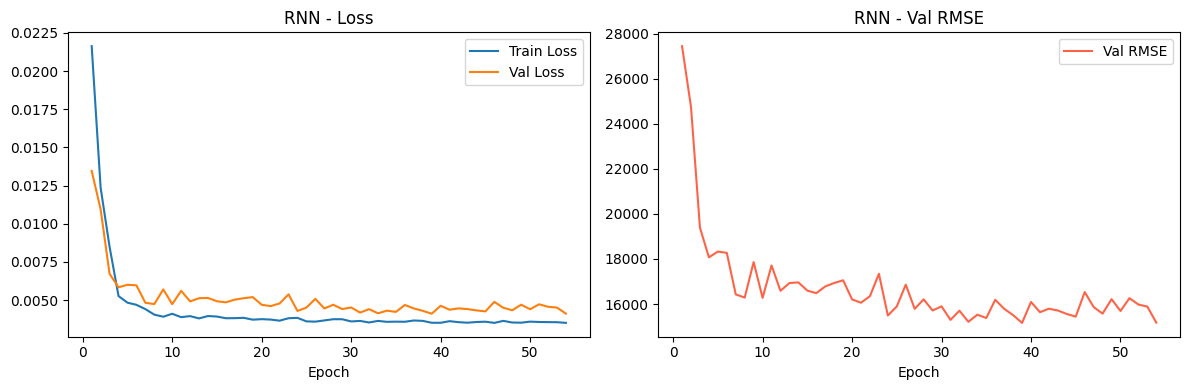

In [25]:
hist_df = pd.DataFrame(rnn_history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_df['epoch'], hist_df['tr_loss'], label='Train Loss')
axes[0].plot(hist_df['epoch'], hist_df['vl_loss'], label='Val Loss')
axes[0].set_title('RNN - Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].plot(hist_df['epoch'], hist_df['vl_rmse'], color='tomato', label='Val RMSE')
axes[1].set_title('RNN - Val RMSE')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'rnn_learning_curve.png', dpi=120)
plt.show()

## 5.2 Long Short-Term Memory

LSTM memperluas RNN dengan menambahkan mekanisme *gate* (input, forget, output) dan *cell state* sebagai memori jangka panjang. Mekanisme ini dirancang untuk mengatasi *vanishing gradient* dan memungkinkan model mengingat dependensi jangka jauh.

### 5.2.1 Model LSTM dari Nol

In [26]:
class LSTMModel(nn.Module):
    def __init__(
        self,
        input_size=CFG.INPUT_SIZE,
        hidden_size=CFG.HIDDEN_SIZE,
        num_layers=CFG.NUM_LAYERS,
        dropout=CFG.DROPOUT,
        output_size=CFG.OUTPUT_SIZE,
    ):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # ambil output langkah terakhir
        return self.fc(out)

lstm_model = LSTMModel()
print(lstm_model)
print('Parameter LSTM:', sum(p.numel() for p in lstm_model.parameters()))

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Parameter LSTM: 50497


### Pelatihan LSTM

In [27]:
lstm_fold_rmse, lstm_history, lstm_val_preds, lstm_val_labels, lstm_val_dates, lstm_model = \
    run_cv(LSTMModel, CFG.CHECKPOINT_LSTM, 'LSTM', orig_positions)
lstm_val_rmse = float(np.mean(lstm_fold_rmse))
print(f'LSTM Val RMSE (mean): {lstm_val_rmse:.4f}')


[LSTM] Fold 1/1  (train=2799, val=700)
Epoch 001/100  train_loss=0.029800  val_loss=0.012492  val_rmse=26437.77
  [OK] Checkpoint disimpan (val_rmse=26437.77)
Epoch 002/100  train_loss=0.013770  val_loss=0.010816  val_rmse=24599.73
  [OK] Checkpoint disimpan (val_rmse=24599.73)
Epoch 003/100  train_loss=0.010908  val_loss=0.011610  val_rmse=25486.96
Epoch 004/100  train_loss=0.008270  val_loss=0.007102  val_rmse=19934.29
  [OK] Checkpoint disimpan (val_rmse=19934.29)
Epoch 005/100  train_loss=0.006843  val_loss=0.007610  val_rmse=20634.01
Epoch 006/100  train_loss=0.006590  val_loss=0.007304  val_rmse=20215.55
Epoch 007/100  train_loss=0.006510  val_loss=0.007181  val_rmse=20044.85
Epoch 008/100  train_loss=0.006235  val_loss=0.007470  val_rmse=20444.53
Epoch 009/100  train_loss=0.006238  val_loss=0.007264  val_rmse=20159.96
Epoch 010/100  train_loss=0.006103  val_loss=0.007172  val_rmse=20032.15
Epoch 011/100  train_loss=0.005964  val_loss=0.007051  val_rmse=19861.60
  [OK] Checkpoin

### Kurva Pembelajaran LSTM

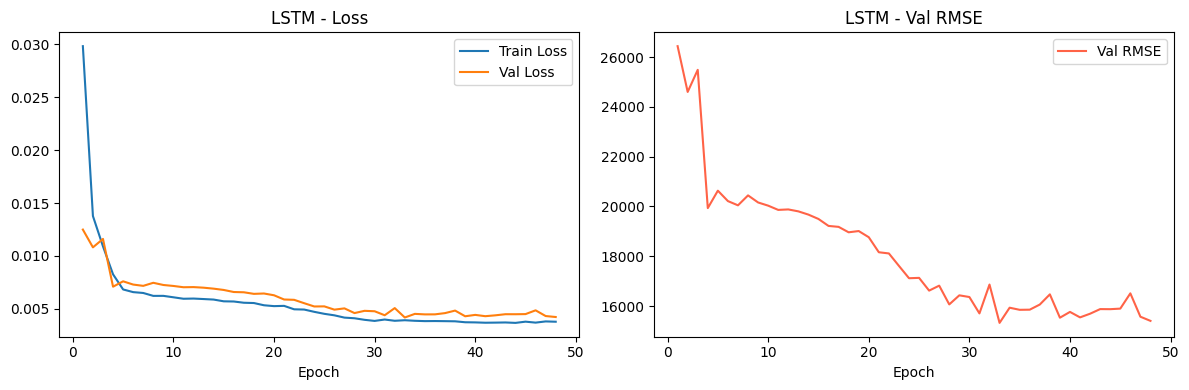

In [28]:
hist_df = pd.DataFrame(lstm_history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_df['epoch'], hist_df['tr_loss'], label='Train Loss')
axes[0].plot(hist_df['epoch'], hist_df['vl_loss'], label='Val Loss')
axes[0].set_title('LSTM - Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].plot(hist_df['epoch'], hist_df['vl_rmse'], color='tomato', label='Val RMSE')
axes[1].set_title('LSTM - Val RMSE')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'lstm_learning_curve.png', dpi=120)
plt.show()

## Validasi: Perbandingan RNN dan LSTM

Kedua model dibandingkan berdasarkan RMSE pada set validasi. Tabel berikut merangkum hasil kuantitatif, diikuti visualisasi prediksi terhadap nilai aktual pada rentang waktu validasi.

  Strategi      : holdout (1 fold)
  RNN  Val RMSE : 15163.1982  (fold: [15163.2])
  LSTM Val RMSE : 15323.6865  (fold: [15323.69])


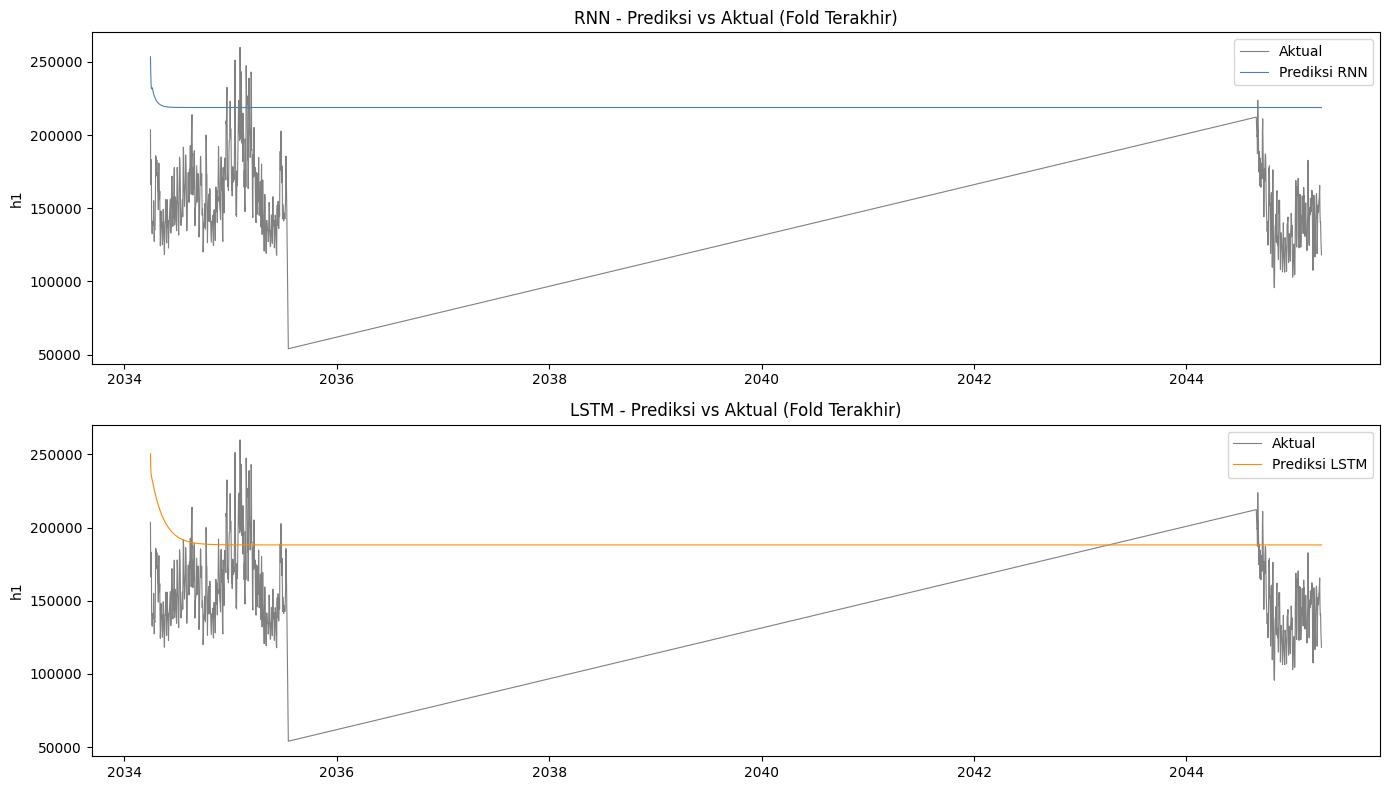

In [29]:
n_folds = len(splits)
print('=' * 50)
print(f'  Strategi      : {CFG.VAL_STRATEGY} ({n_folds} fold)')
print(f'  RNN  Val RMSE : {rnn_val_rmse:.4f}  (fold: {[round(r,2) for r in rnn_fold_rmse]})')
print(f'  LSTM Val RMSE : {lstm_val_rmse:.4f}  (fold: {[round(r,2) for r in lstm_fold_rmse]})')
print('=' * 50)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
for ax, preds, labels, dates, label, color in zip(
    axes,
    [rnn_val_preds,  lstm_val_preds],
    [rnn_val_labels, lstm_val_labels],
    [rnn_val_dates,  lstm_val_dates],
    ['RNN', 'LSTM'],
    ['steelblue', 'darkorange'],
):
    ax.plot(dates, labels, label='Aktual',           color='gray',  linewidth=0.8)
    ax.plot(dates, preds,  label=f'Prediksi {label}', color=color,  linewidth=0.8)
    ax.set_title(f'{label} - Prediksi vs Aktual (Fold Terakhir)')
    ax.set_ylabel('h1')
    ax.legend()
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'validation_comparison.png', dpi=120)
plt.show()

## Submisi Kaggle

Prediksi data uji dihasilkan menggunakan strategi yang dikontrol `CFG.INFER_MODE`. Pada mode `'multistep'`, model memprediksi seluruh `HORIZON` langkah sekaligus dalam satu *forward pass* dari *seed* `WINDOW_SIZE` nilai terakhir data latih sehingga tidak ada akumulasi kesalahan antarlangkah. Pada mode `'autoregressive'`, setiap prediksi dimasukkan kembali sebagai input untuk langkah berikutnya. Dua berkas submisi dihasilkan, satu untuk setiap arsitektur.

In [30]:
# Seed: WINDOW_SIZE nilai terakhir dari data latih (skala ternormalisasi)
seed_seq = scaled_values[-CFG.WINDOW_SIZE:]
n_test   = len(test_df)

rnn_test_preds  = predict_test(rnn_model,  seed_seq, n_test)
lstm_test_preds = predict_test(lstm_model, seed_seq, n_test)

print(f'Prediksi uji RNN  - min: {rnn_test_preds.min():.2f}, max: {rnn_test_preds.max():.2f}')
print(f'Prediksi uji LSTM - min: {lstm_test_preds.min():.2f}, max: {lstm_test_preds.max():.2f}')

Prediksi uji RNN  - min: 128238.55, max: 218856.67
Prediksi uji LSTM - min: 130423.16, max: 188149.89


In [31]:
submission_rnn = pd.DataFrame({
    CFG.TIME_COL: test_df.index,
    CFG.TARGET_COL: rnn_test_preds,
})
submission_rnn.to_csv(CFG.SUBMISSION_RNN, index=False)
print('Submisi RNN  disimpan:', CFG.SUBMISSION_RNN)
display(submission_rnn.head())

submission_lstm = pd.DataFrame({
    CFG.TIME_COL: test_df.index,
    CFG.TARGET_COL: lstm_test_preds,
})
submission_lstm.to_csv(CFG.SUBMISSION_LSTM, index=False)
print('Submisi LSTM disimpan:', CFG.SUBMISSION_LSTM)
display(submission_lstm.head())

Submisi RNN  disimpan: /kaggle/working/prak4/submission_rnn.csv


,time,h1
0,2045-04-10,128238.546875
1,2045-04-11,136900.484375
2,2045-04-12,140913.093750
3,2045-04-13,142945.390625
4,2045-04-14,143758.015625


Submisi LSTM disimpan: /kaggle/working/prak4/submission_lstm.csv


,time,h1
0,2045-04-10,130423.164062
1,2045-04-11,137295.937500
2,2045-04-12,140594.171875
3,2045-04-13,142366.000000
4,2045-04-14,143602.875000


> ### Insights
> Isi perbandingan kinerja RNN vs LSTM dan komentar atas hasil submisi Kaggle di sini.

---

# Analisis Kesalahan <a name="6"></a>

---

Analisis kesalahan membandingkan prediksi model dengan nilai aktual pada set validasi secara kualitatif maupun kuantitatif. Visualisasi grafik garis memperlihatkan deviasi prediksi dari realisasi sepanjang waktu, sementara distribusi residual mengungkap pola kesalahan sistematis.

## Analisis Kesalahan RNN

Residual dihitung sebagai selisih nilai aktual dikurangi prediksi, kemudian divisualisasikan terhadap waktu untuk mengidentifikasi periode dengan kesalahan tinggi.

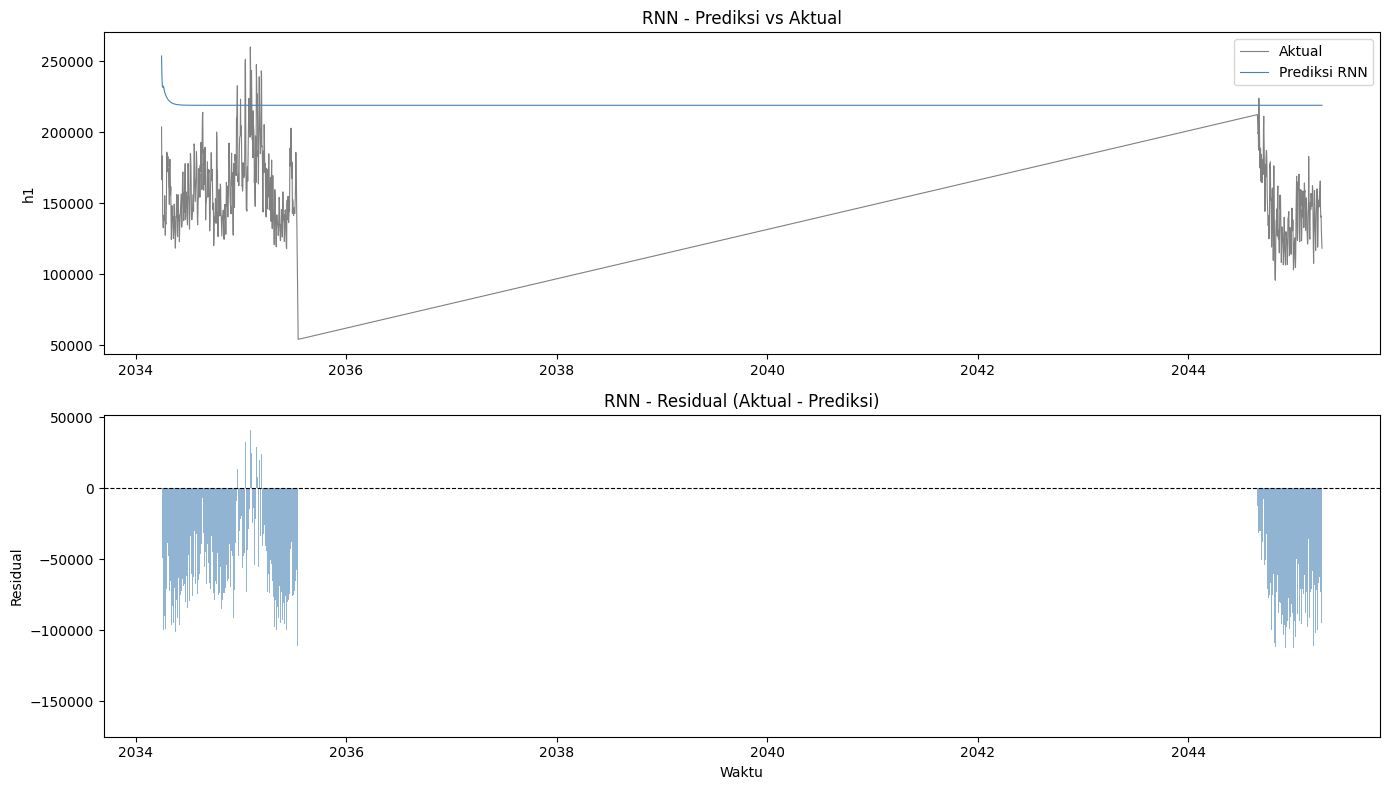

RNN Residual - Mean: -63482.42, Std: 27599.43


In [32]:
rnn_residuals = rnn_val_labels - rnn_val_preds

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(rnn_val_dates, rnn_val_labels, label='Aktual',      color='gray',      linewidth=0.8)
axes[0].plot(rnn_val_dates, rnn_val_preds,  label='Prediksi RNN', color='steelblue', linewidth=0.8)
axes[0].set_title('RNN - Prediksi vs Aktual')
axes[0].set_ylabel('h1')
axes[0].legend()

axes[1].bar(rnn_val_dates, rnn_residuals, color='steelblue', alpha=0.6, width=1)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('RNN - Residual (Aktual - Prediksi)')
axes[1].set_ylabel('Residual')
axes[1].set_xlabel('Waktu')

plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'error_rnn.png', dpi=120)
plt.show()

print(f'RNN Residual - Mean: {rnn_residuals.mean():.2f}, Std: {rnn_residuals.std():.2f}')

## Analisis Kesalahan LSTM

Analisis yang sama diterapkan pada model LSTM untuk memungkinkan perbandingan langsung pola kesalahan antara kedua arsitektur.

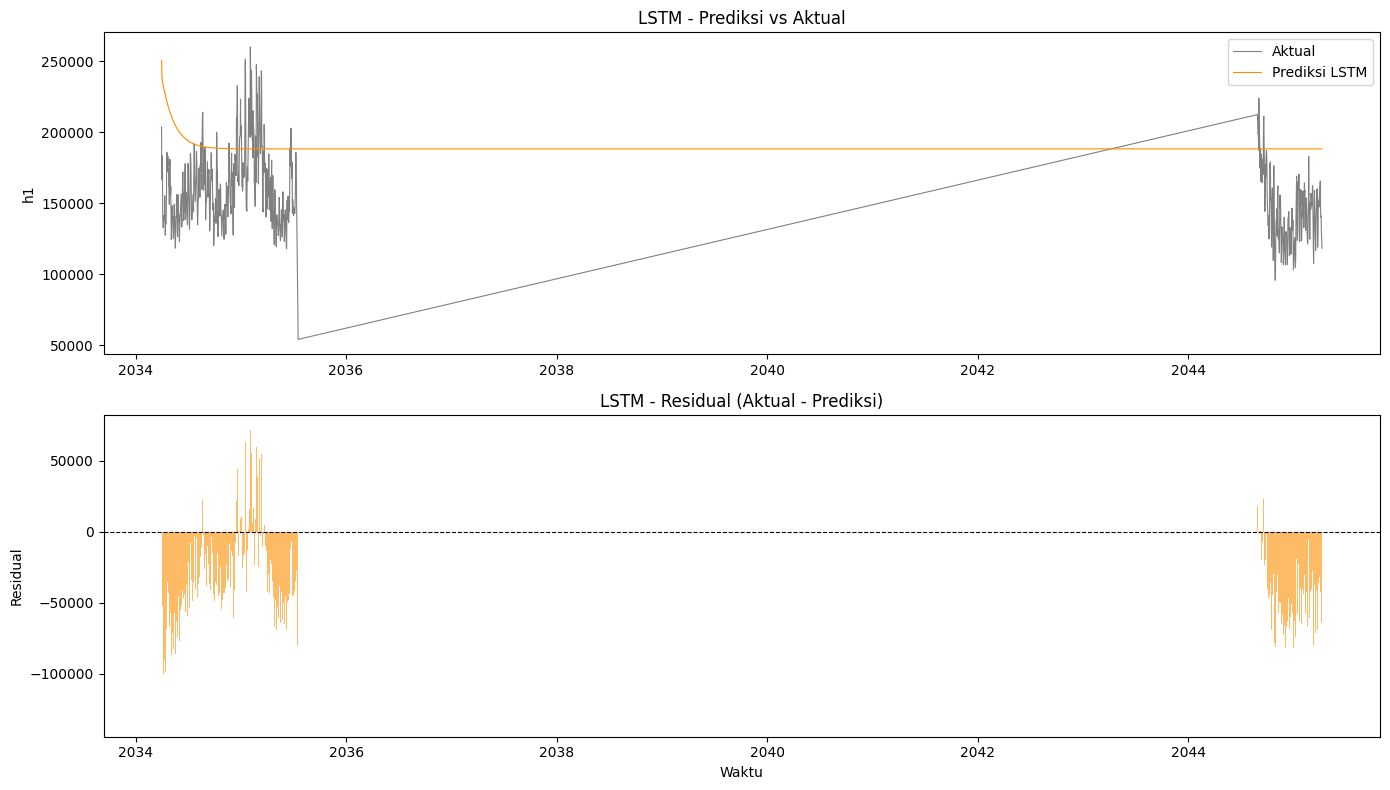

LSTM Residual - Mean: -35464.11, Std: 29182.26


In [33]:
lstm_residuals = lstm_val_labels - lstm_val_preds

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(lstm_val_dates, lstm_val_labels, label='Aktual',       color='gray',       linewidth=0.8)
axes[0].plot(lstm_val_dates, lstm_val_preds,  label='Prediksi LSTM', color='darkorange', linewidth=0.8)
axes[0].set_title('LSTM - Prediksi vs Aktual')
axes[0].set_ylabel('h1')
axes[0].legend()

axes[1].bar(lstm_val_dates, lstm_residuals, color='darkorange', alpha=0.6, width=1)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('LSTM - Residual (Aktual - Prediksi)')
axes[1].set_ylabel('Residual')
axes[1].set_xlabel('Waktu')

plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'error_lstm.png', dpi=120)
plt.show()

print(f'LSTM Residual - Mean: {lstm_residuals.mean():.2f}, Std: {lstm_residuals.std():.2f}')

## Distribusi Residual

Distribusi residual menunjukkan apakah kesalahan model terpusat di sekitar nol atau memiliki bias sistematis ke arah tertentu.

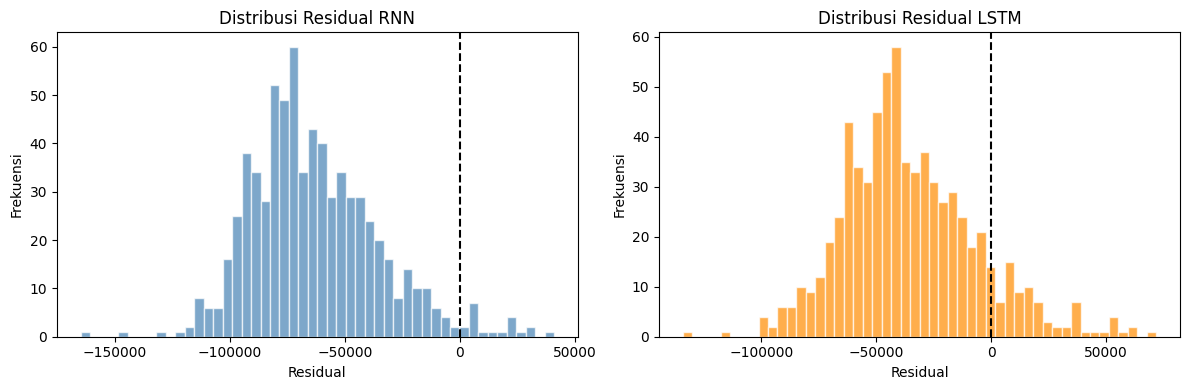

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rnn_residuals,  bins=50, color='steelblue',  alpha=0.7, edgecolor='white')
axes[0].axvline(0, color='black', linestyle='--')
axes[0].set_title('Distribusi Residual RNN')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(lstm_residuals, bins=50, color='darkorange', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Distribusi Residual LSTM')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'error_residual_dist.png', dpi=120)
plt.show()

> ### Insights
> Isi analisis pola kesalahan di sini: apakah ada bias sistematis, periode waktu > tertentu yang sulit diprediksi, dan perbedaan karakteristik kesalahan RNN vs LSTM.

---

# Bundle Output <a name="bundle"></a>

---

Seluruh berkas hasil (model, kurva pembelajaran, visualisasi, dan submisi) dikemas menjadi satu arsip ZIP untuk kemudahan pengunduhan dari Kaggle.

In [35]:
bundle_path = CFG.OUTPUT_DIR / 'figures_bundle.zip'
file_exts   = ['.png', '.pth', '.csv']

with zipfile.ZipFile(bundle_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(CFG.OUTPUT_DIR.iterdir()):
        if f.suffix in file_exts and f != bundle_path:
            zf.write(f, f.name)
            print('[OK]', f.name)

print('Bundle disimpan:', bundle_path)

[OK] cleaning_comparison.png
[OK] eda_acf.png
[OK] eda_decomposition.png
[OK] eda_seasonal_patterns.png
[OK] eda_timeseries.png
[OK] error_lstm.png
[OK] error_residual_dist.png
[OK] error_rnn.png
[OK] lstm_best.pth
[OK] lstm_learning_curve.png
[OK] rnn_best.pth
[OK] rnn_learning_curve.png
[OK] submission_lstm.csv
[OK] submission_rnn.csv
[OK] validation_comparison.png
Bundle disimpan: /kaggle/working/prak4/figures_bundle.zip
